
# 🧠 Finformer: From Transformer Basics to Volatility-Aware AI

This notebook is a comprehensive guide for beginners. We will start from "What is a Transformer?" and end with a state-of-the-art financial forecasting model.

---

## 1. What is a Transformer? (The "Reading" Analogy)

Imagine you are reading this sentence: 
> "The **bank** of the river was muddy, but the **bank** refused the loan."

How do you know the first 'bank' is a piece of land and the second is a financial institution? 
**You look at the surrounding words.**

A **Transformer** is an AI architecture that does exactly this. It uses a mechanism called **"Attention"** to look at all parts of a sequence (words in a sentence or prices in a stock chart) and decide which ones are important for understanding the current point.

### The "Spotlight" Concept
Think of Attention as a **Spotlight**:
- When the AI looks at a specific day's price, it shines a spotlight on previous days.
- If yesterday was a massive crash, the spotlight on "Yesterday" will be very bright.
- If three weeks ago was just a normal day, the spotlight on that day will be dim.



## 2. Visualizing Attention with Code
Let's simulate how an AI "looks" at data. We'll create a fake stock price series and see how a "Spotlight" might move.


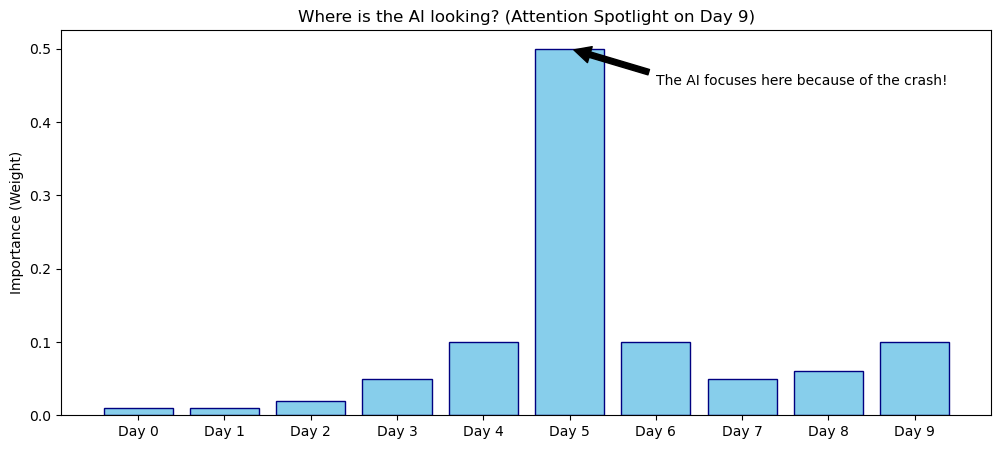

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create fake stock data: A steady rise with one sudden crash
prices = [100, 101, 102, 103, 102, 90, 91, 92, 93, 94] # Day 5 is the crash
days = [f"Day {i}" for i in range(len(prices))]

# 2. Simulate "Attention weights" 
# The AI on Day 9 (price 94) is looking back. 
# It cares most about the crash (Day 5) and the most recent trend.
attention_on_day_9 = [0.01, 0.01, 0.02, 0.05, 0.10, 0.50, 0.10, 0.05, 0.06, 0.10]

plt.figure(figsize=(12, 5))
plt.bar(days, attention_on_day_9, color='skyblue', edgecolor='navy')
plt.title("Where is the AI looking? (Attention Spotlight on Day 9)")
plt.ylabel("Importance (Weight)")
plt.annotate('The AI focuses here because of the crash!', xy=(5, 0.5), xytext=(6, 0.45),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.show()



## 3. Why is Finance harder than Text?

In ChatGPT, words have fixed meanings (e.g., "Apple" is usually a fruit or a company). 
In Finance:
1. **Numbers are Continuous**: A price of 3000 isn't a "word"; it's a value.
2. **Regimes Change**: A 1% drop on a calm day is "Big News." A 1% drop during a market crash is "Nothing."
3. **Stationarity**: The stock market is "non-stationary," meaning the rules of the game change over time.

### The Problem with Standard Transformers
Standard Transformers treat every "Attention Spotlight" the same way. But in a **Volatile (Crazy)** market, you should probably focus more on the **very recent past** because old news becomes irrelevant quickly. In a **Calm** market, you should look at the **long-term trend**.



## 4. Our Solution: Volatility-Aware Attention (VAA)

**Finformer** introduces a "thermostat" for the spotlight.
- When **Volatility is High**: The thermostat turns up the heat, making the spotlight very "sharp" and focused on recent events.
- When **Volatility is Low**: The thermostat cools down, making the spotlight "wide" and blurred across many days.

### Mathematical Intuition
Standard Attention uses a formula: $Softmax(QK^T / \sqrt{d_k})$.
We change it to: $Softmax(QK^T / (\sqrt{d_k} \cdot \mathbf{Volatility\_Scale}))$.

Let's visualize how this "Temperature" changes the spotlight.


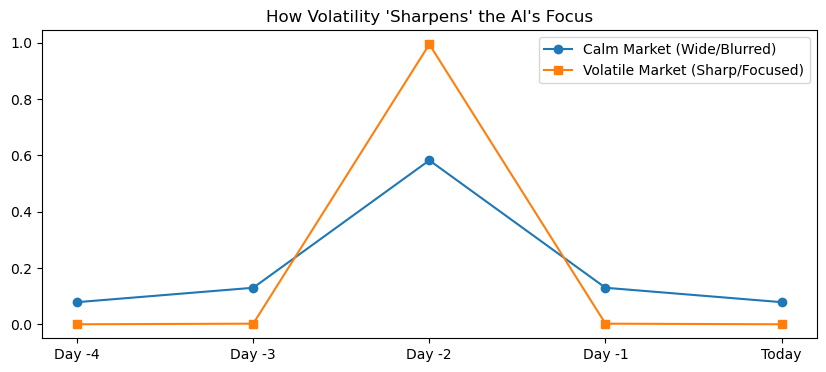

In [2]:

def softmax(x, temperature=1.0):
    e_x = np.exp(x / temperature)
    return e_x / e_x.sum()

raw_scores = np.array([1, 2, 5, 2, 1]) # Day 2 (value 5) is the most interesting

# Calm Market (High Temperature/Scale = 2.0) -> Blurred spotlight
calm_attention = softmax(raw_scores, temperature=2.0)

# Volatile Market (Low Temperature/Scale = 0.5) -> Sharp spotlight
volatile_attention = softmax(raw_scores, temperature=0.5)

plt.figure(figsize=(10, 4))
plt.plot(calm_attention, label='Calm Market (Wide/Blurred)', marker='o')
plt.plot(volatile_attention, label='Volatile Market (Sharp/Focused)', marker='s')
plt.title("How Volatility 'Sharpens' the AI's Focus")
plt.legend()
plt.xticks(range(5), ["Day -4", "Day -3", "Day -2", "Day -1", "Today"])
plt.show()



## 5. Building the "Volatility Meter" (Feature Engineering)

To help the AI know when to sharpen its focus, we calculate several types of volatility:
1. **Historical Volatility**: Standard deviation of recent returns.
2. **Parkinson Volatility**: Uses the High and Low prices (more info than just Close).
3. **GARCH(1,1)**: A statistical model that predicts *tomorrow's* volatility based on today's.

Let's load the **CSI 300** data and look at these "Regimes."


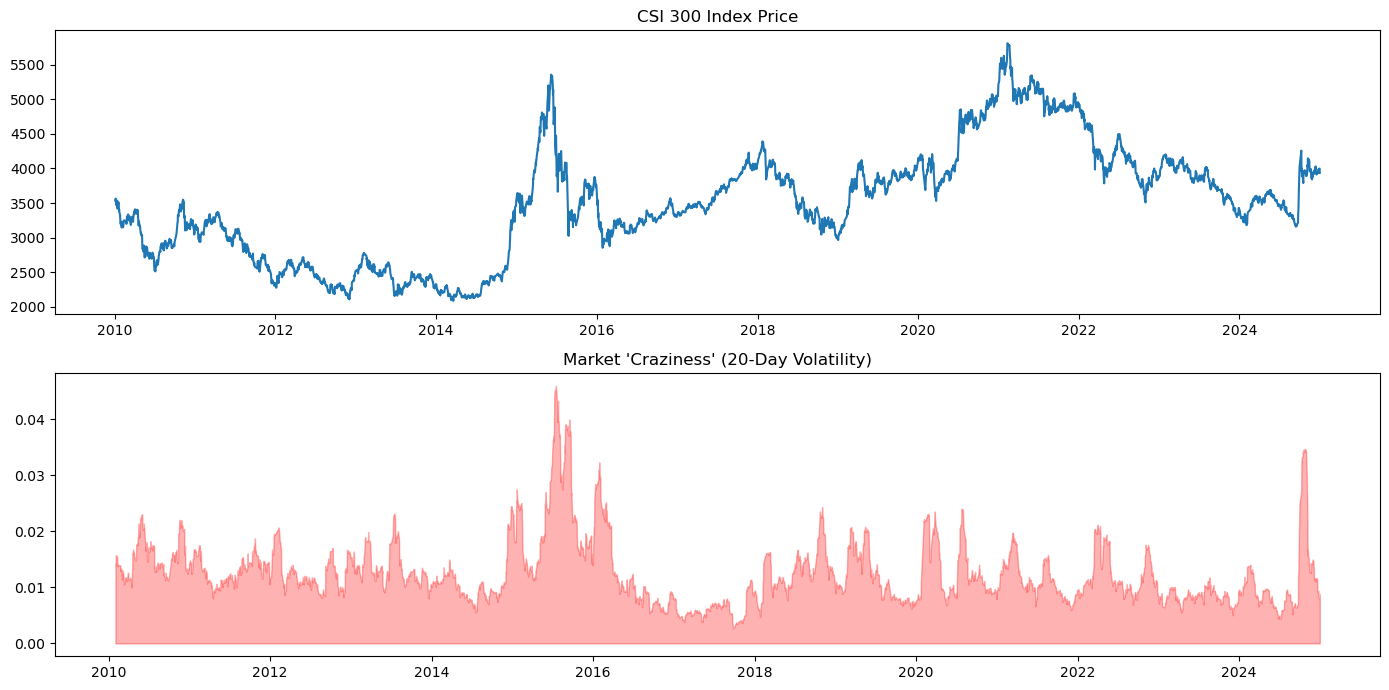

In [3]:

import os
# Load real CSI 300 data
data_path = os.path.join('..', 'data', 'raw', 'csi300_daily.csv')
df = pd.read_csv(data_path)
df['trade_date'] = pd.to_datetime(df['trade_date'])
df['returns'] = df['close'].pct_change()

# Calculate 20-day Volatility
df['vol_20d'] = df['returns'].rolling(20).std()

# Visualize the Regimes
plt.figure(figsize=(14, 7))
plt.subplot(2, 1, 1)
plt.plot(df['trade_date'], df['close'])
plt.title("CSI 300 Index Price")

plt.subplot(2, 1, 2)
plt.fill_between(df['trade_date'], df['vol_20d'], color='red', alpha=0.3)
plt.title("Market 'Craziness' (20-Day Volatility)")
plt.tight_layout()
plt.show()



## 6. Implementing the VAA Layer (Simplified)

Here is how the code looks. We use a small "Vol-Net" (a tiny neural network) to decide the spotlight temperature.


In [4]:

import torch
import torch.nn as nn
import torch.nn.functional as F

class VolNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Takes 4 volatility scales as input
        self.net = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 1), # Outputs 1 temperature scale
            nn.Sigmoid()      # Keeps it between 0 and 1
        )

    def forward(self, vol_features):
        # Maps 0-1 output to a useful scale, e.g., 0.5 to 2.0
        return self.net(vol_features) * 1.5 + 0.5

print("The 'Thermostat' network is defined.")


The 'Thermostat' network is defined.



## 7. How we Analyze the AI
After training, we don't just ask "What is the price?". We ask:
1. **Direction**: Will it go up or down?
2. **Sharpness**: How much did the VAA mechanism actually change the attention weights?

### The "Attention Map"
The ultimate way to analyze a Transformer is the **Attention Map**. It's a heatmap showing exactly which days in history the AI "looked at" to make today's prediction.


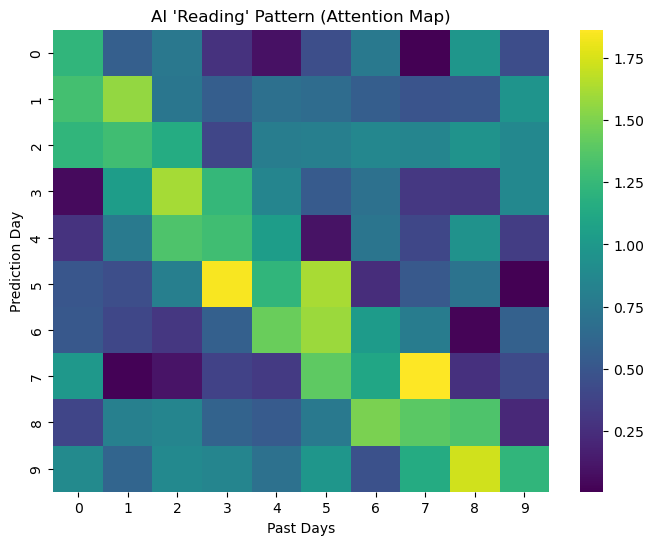

In [5]:

# Dummy Attention Map for 10 days
map_data = np.random.rand(10, 10)
# Make the diagonal and some recent days "brighter"
for i in range(10):
    map_data[i, max(0, i-2):i+1] += 1.0

plt.figure(figsize=(8, 6))
sns.heatmap(map_data, cmap='viridis', annot=False)
plt.title("AI 'Reading' Pattern (Attention Map)")
plt.xlabel("Past Days")
plt.ylabel("Prediction Day")
plt.show()



## Summary for Beginners

1. **Transformer**: An AI that "reads" sequences by focusing (Attention) on relevant parts.
2. **The Problem**: Stock markets change speeds. Calm vs. Panic.
3. **The Innovation (VAA)**: We use a separate AI to measure "Market Craziness" and adjust the Transformer's focus automatically.
4. **The Goal**: By sharpening focus during panic and broadening it during calm, the Finformer makes more accurate predictions than a standard AI.
